# Part 3 — Smoothing & Exponential Methods

**Series:** *Time Series Analysis in Python — from Statistical Modeling to Machine Learning*

Parts 1 and 2 were preparation: we learned to handle time-indexed data and to
test and transform it for stationarity. **Part 3 is where we finally forecast.**
The family we start with — moving averages and *exponential smoothing* — is old,
fast, and remarkably hard to beat. These models absorb trend and seasonality
directly (no differencing required), and they give us the **honest baselines**
every fancier model in later parts must outperform to justify itself.

### What you will learn
1. A minimal but correct **forecasting setup** — train/test split, horizon, error metrics, and naive **baselines**
2. **Moving averages** — simple and weighted — as smoothers and forecasters
3. **Simple Exponential Smoothing (SES)** and the smoothing parameter α
4. **Holt's linear trend** method (and the damped-trend variant)
5. **Holt–Winters** seasonal smoothing — additive vs. multiplicative
6. The **ETS** (Error–Trend–Seasonal) framework and **automatic model selection** by AIC
7. **Prediction intervals** for smoothing models
8. A head-to-head **model comparison** on a real hold-out set

### Dataset
Still `monthly_price.csv` — 356 months (Jan 1992–Aug 2021). We forecast the
**Food Price Index** as our running example (trend-dominated, lightly seasonal),
and use **Rice price** to demonstrate seasonal smoothing.

> **Scope note.** We introduce just enough evaluation to compare models honestly
> here. The *rigorous* treatment — proper cross-validation, walk-forward
> backtesting, and the full metric zoo (MASE, sMAPE, pinball loss) — is **Part
> 6**. Treat this part's single train/test split as a first, deliberately simple
> yardstick.

## 0. Setup, data, and a train/test split

We rebuild the index as before and hold out the **last 24 months** as a test set
we never fit on. Everything is evaluated on that hold-out.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing, Holt, ExponentialSmoothing)
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

# Smoothing optimizers can be chatty; silence the routine convergence noise.
warnings.simplefilter("ignore", ConvergenceWarning)
warnings.simplefilter("ignore", ValueWarning)

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "font.size": 11, "lines.linewidth": 1.6,
})
PALETTE = ["#2b6cb0", "#c05621", "#2f855a", "#6b46c1", "#b83280", "#718096"]

raw = pd.read_csv("monthly_price.csv")
dates = pd.to_datetime(raw["YEAR"].astype(str) + "-" + raw["MONTH"], format="%Y-%b")
df = raw.drop(columns=["ID", "YEAR", "MONTH", "TIME"]).copy()
df.index = dates; df.index.name = "date"
df = df.asfreq("MS")

H = 24                                   # forecast horizon = test length
y = df["Food_Price_Index"]
train, test = y.iloc[:-H], y.iloc[-H:]
print(f"train: {train.index.min().date()} → {train.index.max().date()}  ({len(train)} obs)")
print(f"test : {test.index.min().date()} → {test.index.max().date()}  ({len(test)} obs)")

train: 1992-01-01 → 2019-08-01  (332 obs)
test : 2019-09-01 → 2021-08-01  (24 obs)


## 1. Metrics and baselines — the yardstick

Before any model, define **how we score** and **what we must beat**.

**Error metrics.** Three complementary numbers:

- **MAE** (mean absolute error) — average size of the error, in the data's units.
- **RMSE** (root mean squared error) — like MAE but punishes big misses more.
- **MAPE** (mean absolute percentage error) — scale-free, in %, but unstable near zero.

In [2]:
def mae(actual, pred):  return np.mean(np.abs(actual - pred))
def rmse(actual, pred): return np.sqrt(np.mean((actual - pred) ** 2))
def mape(actual, pred): return np.mean(np.abs((actual - pred) / actual)) * 100

def score(name, actual, pred):
    return {"model": name, "MAE": round(mae(actual, pred), 3),
            "RMSE": round(rmse(actual, pred), 3), "MAPE%": round(mape(actual, pred), 2)}

**Baselines.** A forecast is only impressive relative to something trivial. Three
standard baselines:

- **Naive** — tomorrow equals today; repeat the last observed value.
- **Seasonal naive** — repeat the value from one full season ago (12 months here).
- **Drift** — extend the straight line drawn from the first to the last training point.

If a sophisticated model can't beat these, it isn't earning its complexity.

In [3]:
def naive_forecast(train, h):
    return pd.Series(train.iloc[-1], index=test.index[:h])

def snaive_forecast(train, h, m=12):
    last_season = train.iloc[-m:].values
    reps = int(np.ceil(h / m))
    vals = np.tile(last_season, reps)[:h]
    return pd.Series(vals, index=test.index[:h])

def drift_forecast(train, h):
    slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
    vals = train.iloc[-1] + slope * np.arange(1, h + 1)
    return pd.Series(vals, index=test.index[:h])

baselines = {
    "Naive":          naive_forecast(train, H),
    "Seasonal naive": snaive_forecast(train, H),
    "Drift":          drift_forecast(train, H),
}
baseline_scores = pd.DataFrame([score(n, test, f) for n, f in baselines.items()])
baseline_scores

,model,MAE,RMSE,MAPE%
0,Naive,15.979,21.270,14.30
1,Seasonal naive,14.604,20.141,12.94
2,Drift,14.899,20.090,13.29


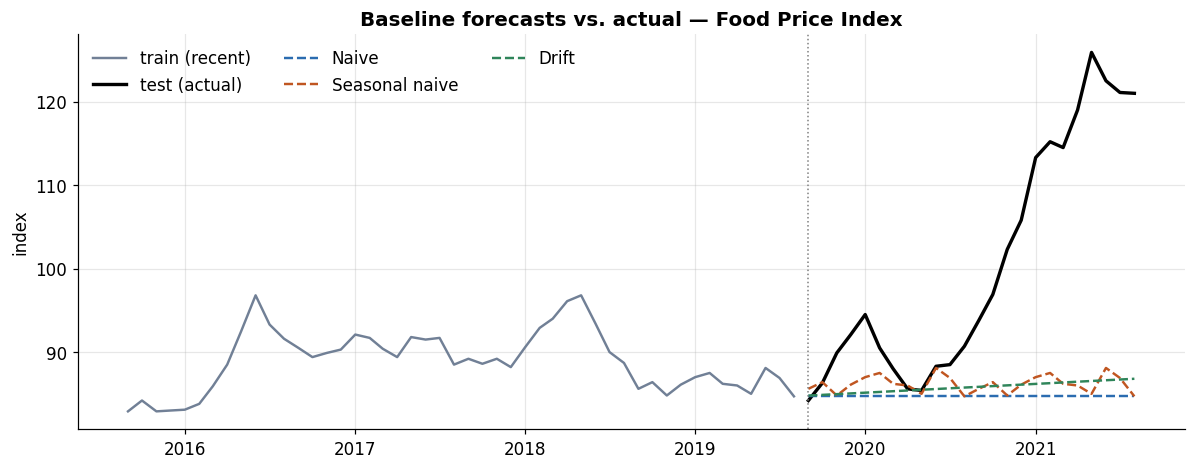

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(train.index[-48:], train.iloc[-48:], color=PALETTE[5], label="train (recent)")
ax.plot(test.index, test, color="black", lw=2.2, label="test (actual)")
for (name, fc), c in zip(baselines.items(), PALETTE):
    ax.plot(fc.index, fc, color=c, ls="--", label=name)
ax.axvline(test.index[0], color="grey", lw=1, ls=":")
ax.set_title("Baseline forecasts vs. actual — Food Price Index")
ax.set_ylabel("index"); ax.legend(frameon=False, ncol=3)
plt.tight_layout(); plt.show()

The naive line is flat at the last observed value; the drift line extends the
**long-run upward slope** of the whole training period; seasonal-naive repeats
last year's shape. We score all three on the hold-out below — they are the bars
any "real" model must clear.

## 2. Moving averages — the simplest smoother

A **moving average (MA)** replaces each point with the mean of a window around it.
It is primarily a **smoother** (for seeing trend through noise), but the last
window mean can also serve as a crude forecast.

- **Trailing MA** uses only past values (`rolling(k).mean()`) — causal, usable for forecasting.
- **Centered MA** averages symmetrically around each point — smoother, but "sees
  the future," so it is for *visualization only*, never forecasting.
- **Weighted MA (WMA)** gives more weight to recent points — a step toward
  exponential smoothing.

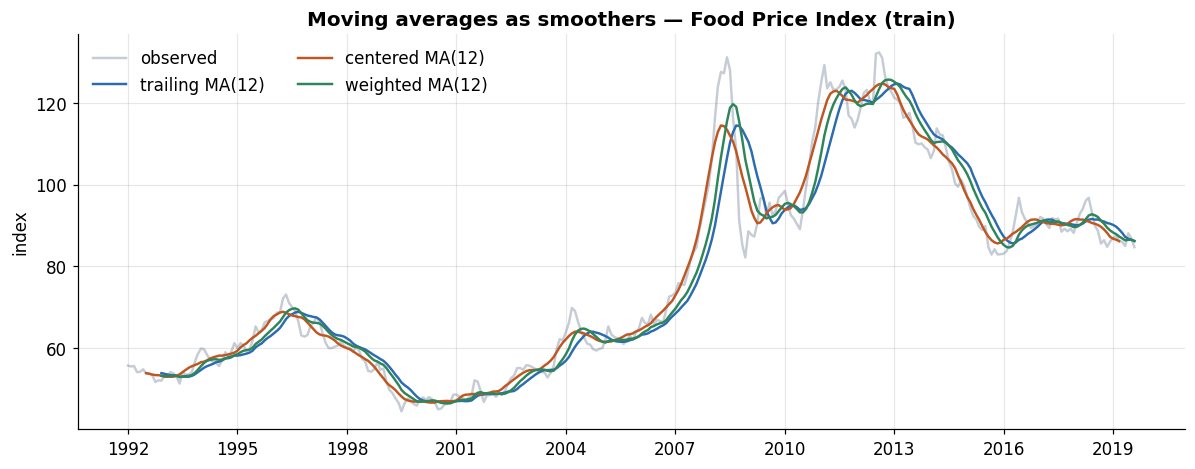

In [5]:
k = 12
trailing = train.rolling(k).mean()
centered = train.rolling(k, center=True).mean()
weights = np.arange(1, k + 1)                       # linearly increasing weights
wma = train.rolling(k).apply(lambda w: np.dot(w, weights) / weights.sum(), raw=True)

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(train.index, train, color=PALETTE[5], alpha=0.4, label="observed")
ax.plot(trailing.index, trailing, color=PALETTE[0], label=f"trailing MA({k})")
ax.plot(centered.index, centered, color=PALETTE[1], label=f"centered MA({k})")
ax.plot(wma.index, wma, color=PALETTE[2], label=f"weighted MA({k})")
ax.set_title("Moving averages as smoothers — Food Price Index (train)")
ax.set_ylabel("index"); ax.legend(frameon=False, ncol=2)
ax.xaxis.set_major_locator(mdates.YearLocator(3))
plt.tight_layout(); plt.show()

Two limitations are visible. The trailing MA **lags** the series (it turns after
the data does), and every MA forecast beyond the training end is just a **flat
line** at the last window mean — it cannot project a trend. Exponential smoothing
fixes the weighting; Holt's method fixes the flatness.

In [6]:
ma_fc = pd.Series(trailing.iloc[-1], index=test.index)   # flat MA(12) forecast
print(score("Moving average (12)", test, ma_fc))

{'model': 'Moving average (12)', 'MAE': np.float64(14.727), 'RMSE': np.float64(20.177), 'MAPE%': np.float64(13.08)}


## 3. Simple Exponential Smoothing (SES)

A moving average weights the last $k$ points **equally** and ignores everything
older. That is arbitrary. **Exponential smoothing** instead weights *all* past
observations, with weights that **decay geometrically** into the past. The one
parameter, the **smoothing level α ∈ (0, 1)**, sets how fast:

$$\hat{y}_{t+1} = \alpha\, y_t + (1-\alpha)\,\hat{y}_t$$

- **α near 1** — react fast, trust recent data, forecasts wiggle.
- **α near 0** — react slowly, heavy smoothing, forecasts are stable.

SES models **level only** — no trend, no seasonality — so its forecast is a
**flat line** at the final smoothed level. It is the right tool for a series that
hovers around a slowly-changing mean.

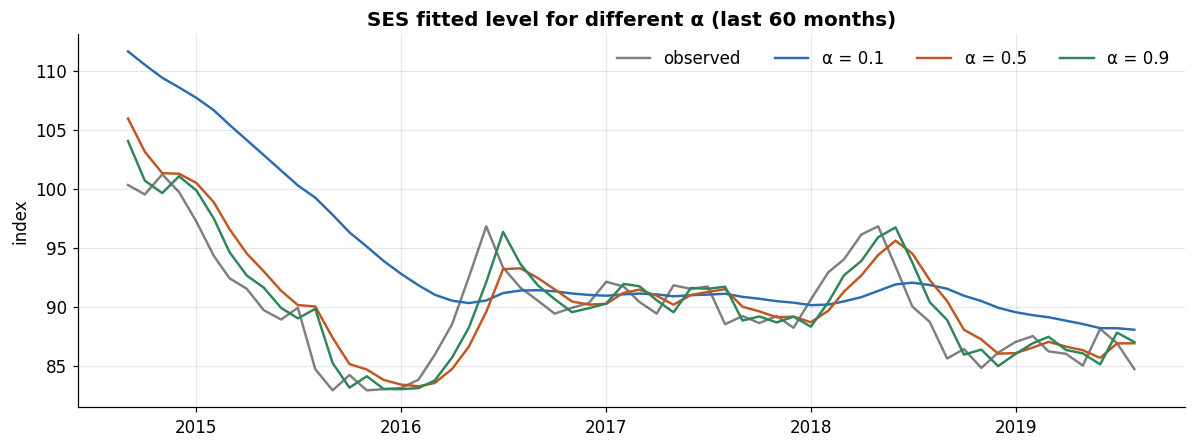

In [7]:
# Effect of alpha (fit level manually to visualize)
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(train.index[-60:], train.iloc[-60:], color="black", alpha=0.5, label="observed")
for a, c in zip([0.1, 0.5, 0.9], PALETTE):
    m = SimpleExpSmoothing(train, initialization_method="estimated").fit(
        smoothing_level=a, optimized=False)
    ax.plot(m.fittedvalues.index[-60:], m.fittedvalues.iloc[-60:], color=c,
            label=f"α = {a}")
ax.set_title("SES fitted level for different α (last 60 months)")
ax.set_ylabel("index"); ax.legend(frameon=False, ncol=4)
plt.tight_layout(); plt.show()

Larger α hugs the data; smaller α produces a smooth, sluggish line. Rather than
guess, let statsmodels **optimize α by maximum likelihood**.

In [8]:
ses = SimpleExpSmoothing(train, initialization_method="estimated").fit()
ses_fc = ses.forecast(H)
print(f"optimized α = {ses.params['smoothing_level']:.3f}")
print(score("SES (optimized)", test, ses_fc))

optimized α = 1.000
{'model': 'SES (optimized)', 'MAE': np.float64(15.979), 'RMSE': np.float64(21.27), 'MAPE%': np.float64(14.3)}


The optimizer pushes **α ≈ 1** — because the Food Price Index is strongly
trending and persistent, SES decides the best "level-only" bet is to trust the
very last value. In other words, **on a trending series SES collapses to the
naive forecast** and inherits its flat-line lag. That is not a failure of the
code; it is SES honestly reporting that a level-only model is the wrong shape
here. The fix is to give the model an explicit **trend**.

## 4. Holt's linear trend method

**Holt** extends SES with a second equation that tracks a **trend**. Now two
components evolve — the **level** (smoothed by α) and the **slope** (smoothed by
**β**) — and the forecast is a **sloped line** rather than a flat one:

$$\hat{y}_{t+h} = \ell_t + h\,b_t$$

where $\ell_t$ is the level and $b_t$ the trend at the end of training.

In [9]:
holt = Holt(train, initialization_method="estimated").fit()
holt_fc = holt.forecast(H)
print(f"α = {holt.params['smoothing_level']:.3f}, "
      f"β = {holt.params['smoothing_trend']:.3f}")
print(score("Holt linear", test, holt_fc))

α = 1.000, β = 0.472
{'model': 'Holt linear', 'MAE': np.float64(28.724), 'RMSE': np.float64(35.417), 'MAPE%': np.float64(26.34)}


### Damped trend

A plain Holt forecast extends the *last* slope forever, which often **over-shoots**
at long horizons — real trends flatten. The **damped-trend** variant multiplies
the slope by a damping factor **φ ∈ (0, 1)** each step ahead, so the forecast
bends toward a horizontal line. Damping is one of the most reliable practical
tweaks in all of forecasting.

α = 1.000, β = 0.501, φ = 0.800


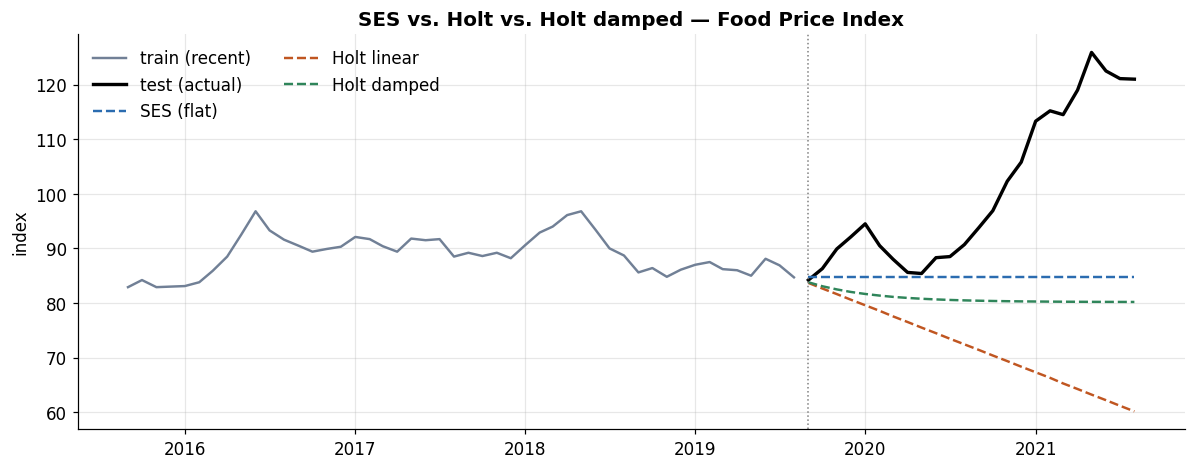

,model,MAE,RMSE,MAPE%
0,SES,15.979,21.270,14.30
1,Holt linear,28.724,35.417,26.34
2,Holt damped,19.717,24.600,18.00


In [10]:
holt_d = Holt(train, damped_trend=True, initialization_method="estimated").fit()
holt_d_fc = holt_d.forecast(H)
print(f"α = {holt_d.params['smoothing_level']:.3f}, "
      f"β = {holt_d.params['smoothing_trend']:.3f}, "
      f"φ = {holt_d.params['damping_trend']:.3f}")

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(train.index[-48:], train.iloc[-48:], color=PALETTE[5], label="train (recent)")
ax.plot(test.index, test, color="black", lw=2.2, label="test (actual)")
ax.plot(ses_fc.index, ses_fc, color=PALETTE[0], ls="--", label="SES (flat)")
ax.plot(holt_fc.index, holt_fc, color=PALETTE[1], ls="--", label="Holt linear")
ax.plot(holt_d_fc.index, holt_d_fc, color=PALETTE[2], ls="--", label="Holt damped")
ax.axvline(test.index[0], color="grey", lw=1, ls=":")
ax.set_title("SES vs. Holt vs. Holt damped — Food Price Index")
ax.set_ylabel("index"); ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()

pd.DataFrame([score("SES", test, ses_fc),
              score("Holt linear", test, holt_fc),
              score("Holt damped", test, holt_d_fc)])

Adding a trend moves the forecast off the flat SES line — but notice it can move
it the **wrong** way. Holt reads the recent slope of the training data (mildly
*downward* into 2019) and projects it forward, whereas the test period actually
**surged** (the 2020–21 food-price spike). So the linear extrapolation heads down
while reality climbs, and it scores *worse* than flat SES on this hold-out;
**damping** limits the damage by flattening the projected slope. This previews a
hard truth: no smoothing model anticipates a shock, and blindly extrapolating a
recent trend can backfire — which is exactly why we judge on a hold-out and let
AIC, not the eye, choose the specification.

## 5. Holt–Winters — adding seasonality

**Holt–Winters (HW)** adds a **third** component and smoothing parameter (**γ**)
for **seasonality**, tracking a repeating pattern of length $m$ (12 for monthly
data). As with decomposition in Part 2, seasonality can enter two ways:

- **Additive** — the seasonal swing is a roughly constant number of units,
  independent of level: $\hat{y}_{t+h} = \ell_t + h b_t + s_{t+h-m}$.
- **Multiplicative** — the swing scales with the level (typical of prices):
  $\hat{y}_{t+h} = (\ell_t + h b_t)\, s_{t+h-m}$.

Because our commodities are only lightly seasonal, we switch to **Rice price** to
make the seasonal component visible, and fit both flavours.

In [11]:
rice = df["Rice_Price"]
r_train, r_test = rice.iloc[:-H], rice.iloc[-H:]

hw_add = ExponentialSmoothing(r_train, trend="add", seasonal="add",
    seasonal_periods=12, initialization_method="estimated").fit()
hw_mul = ExponentialSmoothing(r_train, trend="add", seasonal="mul",
    seasonal_periods=12, initialization_method="estimated").fit()

hw_add_fc, hw_mul_fc = hw_add.forecast(H), hw_mul.forecast(H)
pd.DataFrame([score("HW additive",       r_test, hw_add_fc),
              score("HW multiplicative", r_test, hw_mul_fc)])

,model,MAE,RMSE,MAPE%
0,HW additive,49.564,60.840,9.76
1,HW multiplicative,48.411,59.586,9.54


We can pull the **fitted seasonal factors** straight out of the model — the
recurring 12-month pattern it learned.

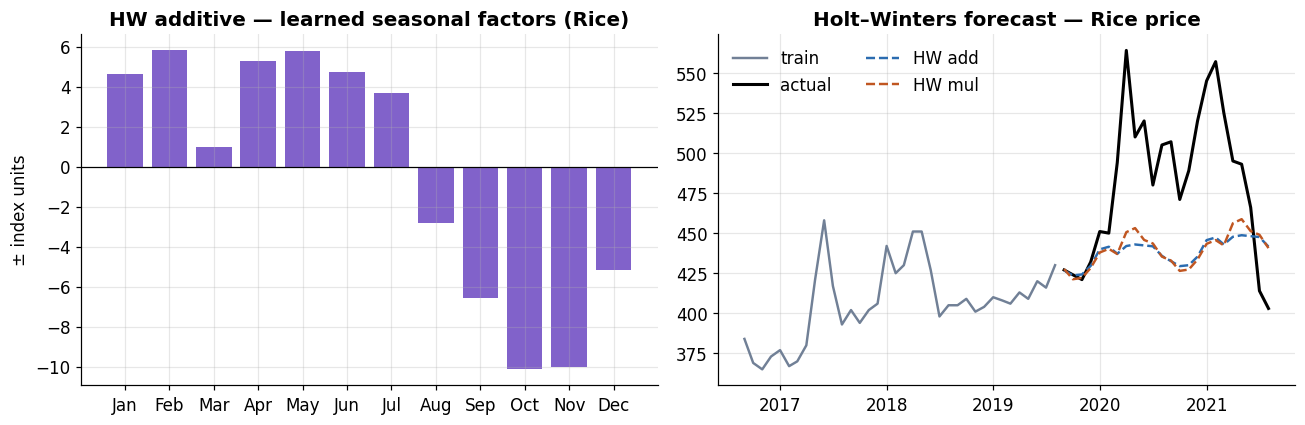

In [12]:
seas = hw_add.params["initial_seasons"]
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(months, seas, color=PALETTE[3], alpha=0.85)
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_title("HW additive — learned seasonal factors (Rice)")
axes[0].set_ylabel("± index units")

axes[1].plot(r_train.index[-36:], r_train.iloc[-36:], color=PALETTE[5], label="train")
axes[1].plot(r_test.index, r_test, color="black", lw=2, label="actual")
axes[1].plot(hw_add_fc.index, hw_add_fc, color=PALETTE[0], ls="--", label="HW add")
axes[1].plot(hw_mul_fc.index, hw_mul_fc, color=PALETTE[1], ls="--", label="HW mul")
axes[1].set_title("Holt–Winters forecast — Rice price")
axes[1].legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()

The seasonal factors are **small relative to the price level** — confirming, yet
again, the "light seasonality" finding from Parts 1–2. Holt–Winters still fits
happily; it simply reports a modest seasonal term. On strongly seasonal data
(electricity, retail) these bars would be large and HW would decisively beat the
non-seasonal methods.

## 6. The ETS framework and automatic selection

SES, Holt, and Holt–Winters are not separate inventions — they are special cases
of one **state-space** family called **ETS**, for **E**rror, **T**rend,
**S**easonal. Each component is tagged:

- **Error:** Additive (A) or Multiplicative (M)
- **Trend:** None (N), Additive (A), or Additive-damped (Ad)
- **Seasonal:** None (N), Additive (A), or Multiplicative (M)

So **ETS(A,N,N)** *is* simple exponential smoothing, **ETS(A,A,N)** is Holt's
linear method, **ETS(A,Ad,A)** is damped Holt–Winters additive, and so on. Naming
the components this way lets us **search the whole family automatically** and pick
the best specification by an information criterion (**AIC**), which rewards fit
and penalizes extra parameters — exactly the principled model selection we want.

In [13]:
def ets_search(train, seasonal_periods=12, positive=True):
    results = []
    errors   = ["add", "mul"] if positive else ["add"]
    trends   = [None, "add"]
    seasonals= [None, "add", "mul"] if positive else [None, "add"]
    for e in errors:
        for t in trends:
            for damped in ([False, True] if t else [False]):
                for s in seasonals:
                    try:
                        m = ETSModel(train, error=e, trend=t, damped_trend=damped,
                                     seasonal=s, seasonal_periods=seasonal_periods,
                                     initialization_method="estimated")
                        r = m.fit(disp=False)
                        tag = f"ETS({e[0].upper()},{'N' if not t else ('Ad' if damped else 'A')},"\
                              f"{'N' if not s else s[0].upper()})"
                        results.append({"spec": tag, "error": e, "trend": t,
                                        "damped": damped, "seasonal": s,
                                        "AIC": round(r.aic, 1), "obj": r})
                    except Exception:
                        pass
    return pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)

search = ets_search(train)
search[["spec", "AIC"]].head(8)

,spec,AIC
0,"ETS(M,Ad,N)",1431.2
1,"ETS(M,Ad,M)",1443.9
2,"ETS(M,Ad,A)",1445.7
3,"ETS(M,N,N)",1461.6
4,"ETS(M,A,N)",1462.2
5,"ETS(M,N,M)",1475.1
6,"ETS(M,A,M)",1475.3
7,"ETS(M,N,A)",1477.7


The lowest-AIC specification is our **automatically selected** model. Let's refit
the winner, forecast, and score it against everything so far.

In [14]:
best = search.iloc[0]
best_ets = best["obj"]
ets_fc = best_ets.forecast(H)
print("Selected by AIC:", best["spec"], " (AIC =", best["AIC"], ")")
print(score(best["spec"], test, ets_fc))

Selected by AIC: ETS(M,Ad,N)  (AIC = 1431.2 )
{'model': 'ETS(M,Ad,N)', 'MAE': np.float64(18.834), 'RMSE': np.float64(23.806), 'MAPE%': np.float64(17.12)}


## 7. Prediction intervals

A point forecast without an interval is overconfident. The ETS state-space form
gives **prediction intervals** analytically: `get_prediction(...).summary_frame()`
returns the mean plus `pi_lower` / `pi_upper`. Intervals **widen with the
horizon** — uncertainty compounds the further ahead you look.

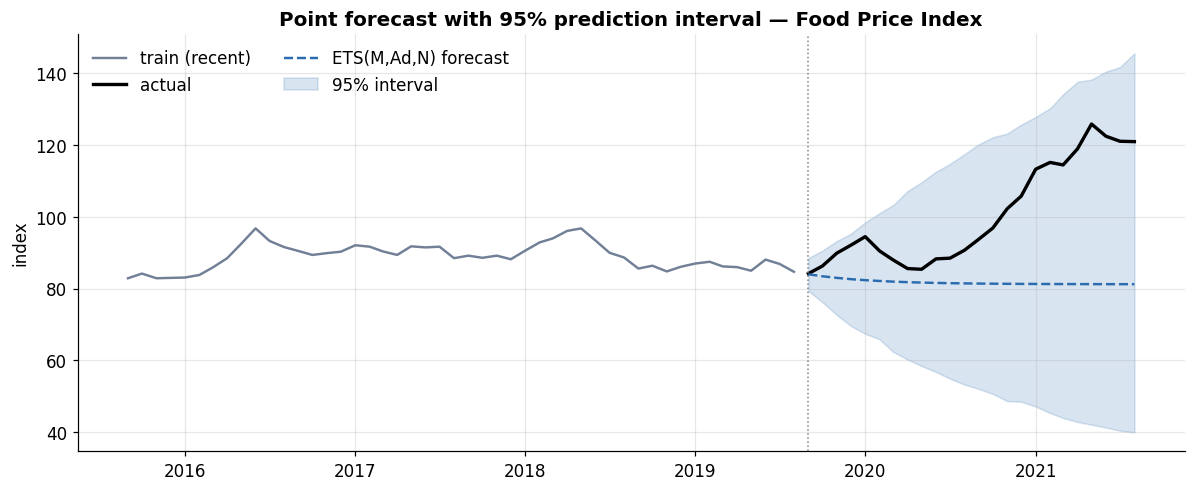

share of actual test points inside the 95% band: 100%


In [15]:
pred = best_ets.get_prediction(start=len(train), end=len(train) + H - 1)
sf = pred.summary_frame(alpha=0.05)     # 95% interval
sf.index = test.index

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(train.index[-48:], train.iloc[-48:], color=PALETTE[5], label="train (recent)")
ax.plot(test.index, test, color="black", lw=2.2, label="actual")
ax.plot(sf.index, sf["mean"], color=PALETTE[0], ls="--", label=f"{best['spec']} forecast")
ax.fill_between(sf.index, sf["pi_lower"], sf["pi_upper"], color=PALETTE[0],
                alpha=0.18, label="95% interval")
ax.axvline(test.index[0], color="grey", lw=1, ls=":")
ax.set_title("Point forecast with 95% prediction interval — Food Price Index")
ax.set_ylabel("index"); ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()

covered = ((test >= sf["pi_lower"]) & (test <= sf["pi_upper"])).mean() * 100
print(f"share of actual test points inside the 95% band: {covered:.0f}%")

The band fans out with distance, and we can check **calibration** directly: for a
well-specified 95% interval, roughly 95% of actual points should fall inside.
Reporting that coverage number is a good habit — an interval that is too narrow is
worse than no interval, because it hides risk.

## 8. Head-to-head comparison

Finally, put every model on the same hold-out and rank them. This is the payoff:
a single table that says which method wins **and** whether any of them beats the
trivial baselines.

In [16]:
all_forecasts = {
    "Naive":          baselines["Naive"],
    "Seasonal naive": baselines["Seasonal naive"],
    "Drift":          baselines["Drift"],
    "Moving avg (12)": ma_fc,
    "SES":            ses_fc,
    "Holt linear":    holt_fc,
    "Holt damped":    holt_d_fc,
    best["spec"]:     ets_fc,
}
leaderboard = (pd.DataFrame([score(n, test, f) for n, f in all_forecasts.items()])
                 .sort_values("RMSE").reset_index(drop=True))
leaderboard

,model,MAE,RMSE,MAPE%
0,Drift,14.899,20.090,13.29
1,Seasonal naive,14.604,20.141,12.94
2,Moving avg (12),14.727,20.177,13.08
3,Naive,15.979,21.270,14.30
4,SES,15.979,21.270,14.30
5,"ETS(M,Ad,N)",18.834,23.806,17.12
6,Holt damped,19.717,24.600,18.00
7,Holt linear,28.724,35.417,26.34


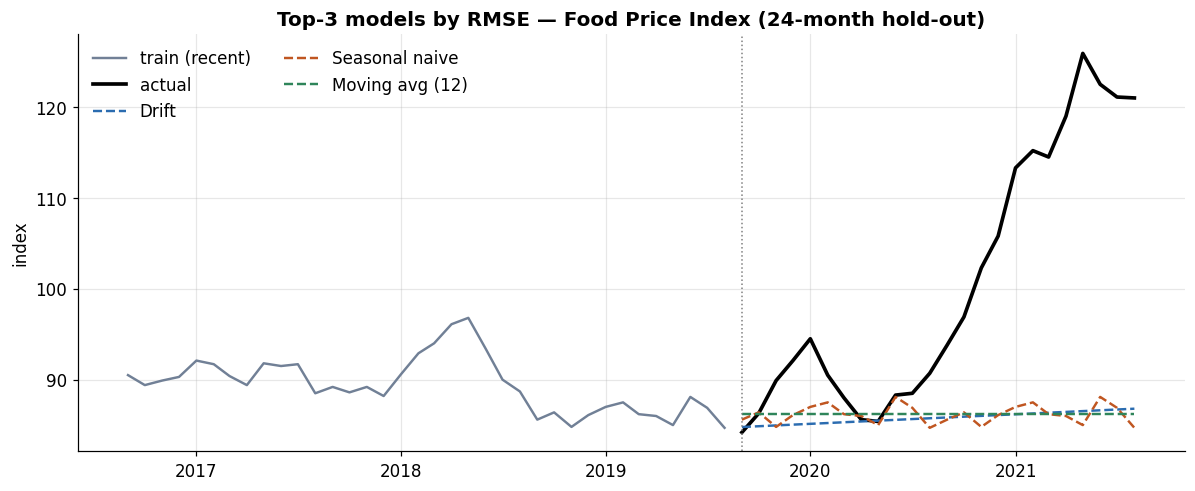

Best model : Drift  (RMSE 20.09)
Best baseline RMSE: 20.09  ->  baseline wins!


In [17]:
top3 = leaderboard["model"].head(3).tolist()
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(train.index[-36:], train.iloc[-36:], color=PALETTE[5], label="train (recent)")
ax.plot(test.index, test, color="black", lw=2.4, label="actual")
for name, c in zip(top3, PALETTE):
    ax.plot(all_forecasts[name].index, all_forecasts[name], color=c, ls="--",
            label=name)
ax.axvline(test.index[0], color="grey", lw=1, ls=":")
ax.set_title(f"Top-3 models by RMSE — Food Price Index ({H}-month hold-out)")
ax.set_ylabel("index"); ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()

winner = leaderboard.iloc[0]
best_base = leaderboard[leaderboard.model.isin(["Naive","Seasonal naive","Drift"])]["RMSE"].min()
print(f"Best model : {winner['model']}  (RMSE {winner['RMSE']})")
print(f"Best baseline RMSE: {best_base}  ->  "
      f"{'the model beats the baseline' if winner['RMSE'] < best_base else 'baseline wins!'}")

Two lessons this table teaches — both more valuable than any single winner:

1. **Always check against baselines.** If the best "real" model can't beat naive
   or drift, the honest conclusion is that the series has little exploitable
   structure at this horizon, not that you need a bigger model.
2. **Complexity must earn its place.** Trend/damping/seasonality each help only
   when the data actually contains that component — which is why AIC-based
   selection, not habit, should choose the specification.

## 9. Exercises

1. **α sensitivity.** Fit SES to `VIX_Index` with α ∈ {0.05, 0.3, 0.8}; plot the
   fitted level and note which best tracks the volatility spikes.
2. **Damping matters.** Forecast `Energy_Price_Index` 24 months ahead with Holt
   linear vs. Holt damped. Which overshoots, and by how much (RMSE)?
3. **Seasonal or not?** Fit HW additive and multiplicative to `Maize_Price` and
   compare to a non-seasonal Holt on the same hold-out. Does seasonality help?
4. **Auto-ETS everywhere.** Run `ets_search` on all three crop series and report
   each selected specification. Do trend/seasonal choices agree with Parts 1–2?
5. **Interval calibration.** For the best ETS on `Rice_Price`, compute the % of
   test points inside the 80% and 95% intervals. Are the intervals well-calibrated?

In [18]:
# --- Solution to Exercise 2 ---
en = df["Energy_Price_Index"]; en_tr, en_te = en.iloc[:-H], en.iloc[-H:]
lin = Holt(en_tr, initialization_method="estimated").fit().forecast(H)
dmp = Holt(en_tr, damped_trend=True, initialization_method="estimated").fit().forecast(H)
pd.DataFrame([score("Energy — Holt linear", en_te, lin),
              score("Energy — Holt damped", en_te, dmp)])

,model,MAE,RMSE,MAPE%
0,Energy — Holt linear,32.578,42.960,44.61
1,Energy — Holt damped,15.534,18.723,25.56


## 10. Key takeaways

- **Forecast against baselines.** Naive, seasonal-naive, and drift are the bar; a
  model that can't clear it hasn't earned its complexity.
- **Moving averages** smooth but **lag**, and forecast a flat line — fine for
  trend visualization, weak for projection.
- **SES** weights the past with geometrically decaying weights (one parameter, α);
  it models **level only**, so on a trending series it degenerates toward naive.
- **Holt** adds a **trend** (β); **damping** (φ) keeps long horizons from
  overshooting and is a reliable default.
- **Holt–Winters** adds **seasonality** (γ), additive or multiplicative — the
  latter for swings that scale with level.
- **ETS** unifies all of these as (Error, Trend, Seasonal) states, enabling
  **automatic selection by AIC** and **analytic prediction intervals**. Always
  report an interval, and check its **coverage**.

### What's next — Part 4: the ARIMA family
Part 4 takes the other classical route: instead of smoothing components, it models
a series' **autocorrelation** directly with **AR**, **MA**, **ARIMA**, and
**SARIMA**. The stationarity tests and ACF/PACF reading from Part 2 become the
tools for choosing model orders — and we'll benchmark ARIMA head-to-head against
today's ETS winner.